# Advanced Layer Types — CNNs and Hyperparameter Tuning

This notebook is based on [episode 4](https://carpentries-lab.github.io/deep-learning-intro/4-advanced-layer-types.html) and introduces **Convolutional Neural Networks (CNNs)**, key regularisation techniques (dropout, max-pooling), and automated **hyperparameter search** with Keras Tuner, applied to a 10-class image classification task using the [Dollar Street dataset](https://zenodo.org/records/10970014).

> **Platform:** Tested on **UCL's Unified AI Platform** (5 CPUs, 64 GB RAM). Runs in any standard environment with the required dependencies installed.

> **Support:** Contact [ARC.Collaborations@ucl.ac.uk](mailto:ARC.Collaborations@ucl.ac.uk) for help with AI platforms, GPUs, or Carpentries training.

---

| Shortcut | Action |
|---|---|
| `Shift + Enter` | Run current cell, move to next |
| `Alt + Enter` | Run current cell, insert new cell below |
| `Ctrl + Shift + F9` | Restart kernel and run all cells |

## 1. System Information

In [1]:
import sys, platform
from datetime import datetime

print(f"Date/Time : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Python    : {sys.version}")
print(f"Platform  : {platform.platform()}")
print(f"Machine   : {platform.machine()}")

Date/Time : 2026-05-28 21:15:24
Python    : 3.11.10 | packaged by conda-forge | (main, Sep 30 2024, 18:08:57) [GCC 13.3.0]
Platform  : Linux-5.14.0-570.30.1.el9_6.x86_64-x86_64-with-glibc2.35
Machine   : x86_64


## 2. Imports, Configuration

All imports are collected here. The `DATA_FOLDER` path is set once and reused throughout, update it if you store the data elsewhere.

In [2]:
# Standard library
import time
import pathlib

# Numerical & visualisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML / DL
import tensorflow
import tensorboard
import sklearn
import keras_tuner
from tensorflow import keras

print("All packages imported successfully.")

I0000 00:00:1780002927.401290 1725110 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


All packages imported successfully.


In [3]:
# ── Path configuration ───────────────────────────────────────────────────────
# Update DATA_FOLDER if you store data in a different location.
DATA_FOLDER = pathlib.Path('/home/jovyan/data/dataset_dollarstreet')

# Fix random seed for reproducibility
RANDOM_SEED = 2
keras.utils.set_random_seed(RANDOM_SEED)

## 3. Download Data

The Dollar Street dataset contains 64×64 RGB images of household objects from homes around the world, labelled into 10 categories.

In [4]:
# Create the data directory (no-op if it already exists)
DATA_FOLDER.mkdir(parents=True, exist_ok=True)
print(f"Data folder: {DATA_FOLDER}")

Data folder: /home/jovyan/data/dataset_dollarstreet


In [5]:
# Download the four .npy splits from Zenodo (-nc skips files already present)
ZENODO_BASE = "https://zenodo.org/records/10970014/files"
for fname in ["train_images.npy", "train_labels.npy",
              "test_images.npy",  "test_labels.npy"]:
    !wget -nc -q -P {DATA_FOLDER} {ZENODO_BASE}/{fname}
    print(f"  {'OK' if (DATA_FOLDER / fname).exists() else 'MISSING':6}  {fname}")

  OK      train_images.npy
  OK      train_labels.npy
  OK      test_images.npy
  OK      test_labels.npy


## 4. Load & Explore Data

In [6]:
train_images = np.load(DATA_FOLDER / 'train_images.npy')
val_images   = np.load(DATA_FOLDER / 'test_images.npy')
train_labels = np.load(DATA_FOLDER / 'train_labels.npy')
val_labels   = np.load(DATA_FOLDER / 'test_labels.npy')

print(f"train_images : {train_images.shape}  dtype={train_images.dtype}  "
      f"range=[{train_images.min()}, {train_images.max()}]")
print(f"val_images   : {val_images.shape}")
print(f"train_labels : {train_labels.shape}  classes {train_labels.min()}–{train_labels.max()}")

train_images : (878, 64, 64, 3)  dtype=int32  range=[0, 255]
val_images   : (293, 64, 64, 3)
train_labels : (878,)  classes 0–9


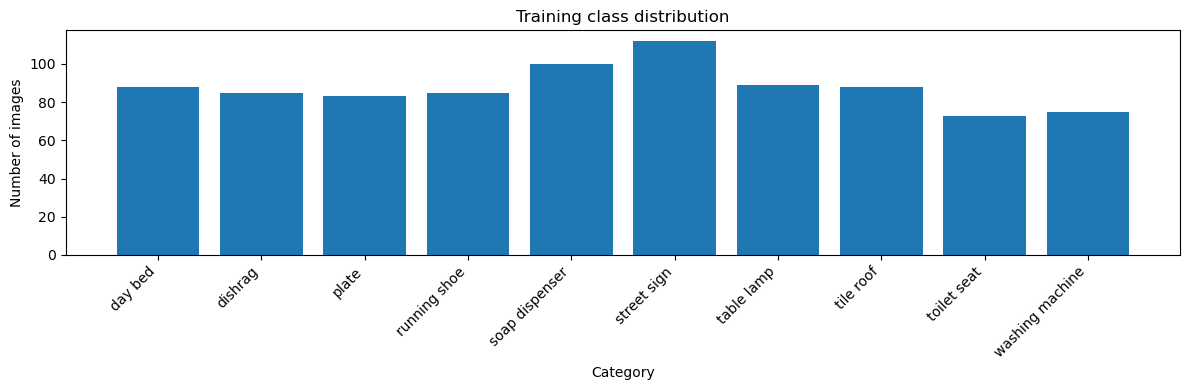

In [7]:
# Integer label → human-readable category name
LABEL_TO_CATEGORY = {
    0: "day bed",       1: "dishrag",      2: "plate",
    3: "running shoe",  4: "soap dispenser", 5: "street sign",
    6: "table lamp",    7: "tile roof",    8: "toilet seat",
    9: "washing machine"
}

# Class distribution in the training set
unique_classes, counts = np.unique(train_labels, return_counts=True)
class_names = [LABEL_TO_CATEGORY[i] for i in unique_classes]

plt.figure(figsize=(12, 4))
plt.bar(class_names, counts)
plt.xticks(rotation=45, ha='right')
plt.xlabel("Category"); plt.ylabel("Number of images")
plt.title("Training class distribution")
plt.tight_layout()
plt.show()

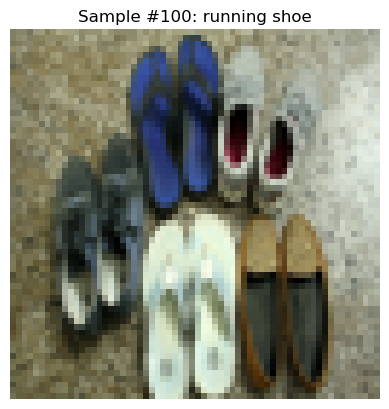

In [8]:
# Inspect a sample image (change SAMPLE_IDX to view a different one)
SAMPLE_IDX = 100
label_name = LABEL_TO_CATEGORY[train_labels[SAMPLE_IDX]]

plt.imshow(train_images[SAMPLE_IDX])
plt.title(f"Sample #{SAMPLE_IDX}: {label_name}")
plt.axis('off')
plt.show()

## 5. Normalise Pixel Values

Neural networks converge faster when inputs are small. We rescale RGB values from [0, 255] to [0, 1].

In [9]:
train_images = train_images / 255.0
val_images   = val_images   / 255.0
print(f"Pixel range after normalisation: [{train_images.min():.1f}, {train_images.max():.1f}]")

Pixel range after normalisation: [0.0, 1.0]


## 6. Why CNNs? The Dense Baseline

A flat Dense layer applied to a 64×64 RGB image (12,288 inputs) requires a huge number of parameters and ignores spatial structure. Let's see how many parameters a single hidden layer of 100 neurons needs.

In [10]:
width, height = 64, 64
n_input = width * height * 3  # 12,288 per image
n_params = (n_input * 100) + 100  # weights + biases for one Dense(100)
print(f"Input dimensions : {n_input:,}")
print(f"Parameters (1 Dense layer of 100 neurons): {n_params:,}")

Input dimensions : 12,288
Parameters (1 Dense layer of 100 neurons): 1,228,900


In [12]:
# Dense baseline: flatten → Dense(100), ignores spatial structure
inputs  = keras.Input(shape=(n_input,)) #shape: A shape tuple 
outputs = keras.layers.Dense(units=100)(inputs)
model_param_demo = keras.models.Model(inputs=inputs, outputs=outputs)
model_param_demo.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │     1,228,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,228,900 (4.69 MB)

 Trainable params: 1,228,900 (4.69 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Basic CNN (Conv2D + Flatten)

Convolutional layers learn local spatial features (edges, textures) with far fewer parameters than fully-connected layers.

In [14]:
inputs  = keras.Input(shape=train_images.shape[1:])
x       = keras.layers.Conv2D(filters=50, kernel_size=(3, 3), activation='relu')(inputs)
x       = keras.layers.Conv2D(filters=50, kernel_size=(3, 3), activation='relu')(x)
x       = keras.layers.Flatten()(x)
outputs = keras.layers.Dense(units=10)(x)

model_basic_cnn = keras.Model(inputs=inputs, outputs=outputs, name="basic_cnn")
model_basic_cnn.summary()

Model: "basic_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 50)     │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 60, 60, 50)     │        22,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 180000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │     1,800,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,823,960 (6.96 MB)

 Trainable params: 1,823,960 (6.96 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Kernel size = 3 × 3
# Input channels = 3
# Filters = 50
# (3×3×3×50)+50 =  1,400 
# (3×3×50×50)+50 = =22550
# (60, 60, 50) → Flatten → 180000
# (180000×10)+10=1,800,000+10=1,800,010

# 🔥 Why Flatten makes parameters explode
# Your model goes from:
# 60×60×50 = 180,000 features
# That is why Dense layer dominates parameters.
# Most CNN designs avoid this by using:
# GlobalAveragePooling2D
# or more conv + pooling layers


## 8. CNN with MaxPooling

`MaxPooling2D` down-samples feature maps by keeping only the maximum value in each 2×2 window, this reduces spatial dimensions, cutting parameters and introducing translation invariance.

In [18]:
def create_nn(input_shape):
    """CNN with two Conv+MaxPool blocks, a Dense hidden layer, and a 10-class output."""    
    inputs  = keras.Input(shape=input_shape)
    x       = keras.layers.Conv2D(filters=50, kernel_size=(3, 3), activation='relu')(inputs)
    x       = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x       = keras.layers.Conv2D(filters=50, kernel_size=(3, 3), activation='relu')(x)
    x       = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x       = keras.layers.Flatten()(x)
    x       = keras.layers.Dense(units=50, activation='relu')(x)
    outputs = keras.layers.Dense(units=10)(x)
    return keras.Model(inputs=inputs, outputs=outputs, name="cnn_with_maxpool")

def compile_model(model):
    """Compile with Adam + sparse categorical cross-entropy + accuracy."""    
    model.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
    )

def plot_history(history, metrics):
    """Plot training and validation metrics."""    
    history_df = pd.DataFrame.from_dict(history.history)
    sns.lineplot(data=history_df[metrics])
    plt.xlabel("Epoch"); plt.ylabel("Metric value")

model = create_nn(input_shape=train_images.shape[1:])
compile_model(model)
model.summary()

Model: "cnn_with_maxpool"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 62, 62, 50)     │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 29, 29, 50)     │        22,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9800)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 50)             │       490,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 514,510 (1.96 MB)

 Trainable params: 514,510 (1.96 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - accuracy: 0.0968 - loss: 2.3130 - val_accuracy: 0.1126 - val_loss: 2.2750
Epoch 2/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.1834 - loss: 2.2195 - val_accuracy: 0.2116 - val_loss: 2.1822
Epoch 3/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.2699 - loss: 2.0602 - val_accuracy: 0.2491 - val_loss: 2.1127
Epoch 4/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.3645 - loss: 1.8478 - val_accuracy: 0.2833 - val_loss: 2.0518
Epoch 5/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 0.4408 - loss: 1.6423 - val_accuracy: 0.2730 - val_loss: 2.1112

Training completed in 15.4s


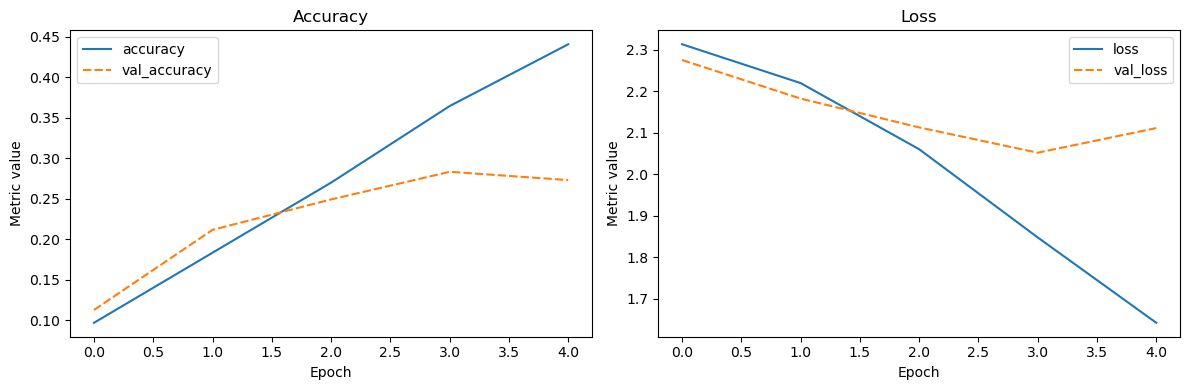

In [19]:
start_time = time.time()
history = model.fit(
    train_images, train_labels,
    epochs=5,
    validation_data=(val_images, val_labels)
)
elapsed = time.time() - start_time
print(f"\nTraining completed in {elapsed:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plt.sca(axes[0]); plot_history(history, ['accuracy', 'val_accuracy']); plt.title("Accuracy")
plt.sca(axes[1]); plot_history(history, ['loss', 'val_loss']);         plt.title("Loss")
plt.tight_layout(); plt.show()

## 9. Dense vs CNN Comparison

Train a fully-connected network for 20 epochs and compare accuracy with the CNN.

In [20]:
def create_dense_model(input_shape):
    """Fully-connected baseline: flatten → Dense(50) × 2 → Dense(10)."""    
    inputs  = keras.Input(shape=input_shape)
    x       = keras.layers.Flatten()(inputs)
    x       = keras.layers.Dense(units=50, activation='relu')(x)
    x       = keras.layers.Dense(units=50, activation='relu')(x)
    outputs = keras.layers.Dense(units=10)(x)
    return keras.models.Model(inputs=inputs, outputs=outputs, name='dense_model')

dense_model = create_dense_model(train_images.shape[1:])
compile_model(dense_model)
dense_model.summary()

Model: "dense_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 50)             │       614,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 617,510 (2.36 MB)

 Trainable params: 617,510 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

Training completed in 9.5s


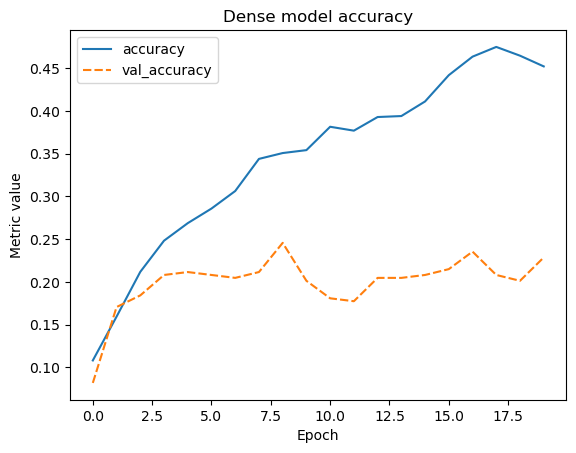

In [21]:
start_time = time.time()
history_dense = dense_model.fit(
    train_images, train_labels,
    epochs=20,
    validation_data=(val_images, val_labels),
    verbose=0
)
elapsed = time.time() - start_time
print(f"Training completed in {elapsed:.1f}s")

plot_history(history_dense, ['accuracy', 'val_accuracy'])
plt.title("Dense model accuracy")
plt.show()

## 10. Adding an Extra Convolutional Layer

A third Conv+MaxPool block can capture higher-level features, though it also shrinks the spatial dimensions further.

In [23]:
def create_nn_extra_layer(input_shape):
    """CNN with three Conv+MaxPool blocks."""    
    inputs  = keras.Input(shape=input_shape)
    x       = keras.layers.Conv2D(filters=50, kernel_size=(3, 3), activation='relu')(inputs)
    x       = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x       = keras.layers.Conv2D(filters=50, kernel_size=(3, 3), activation='relu')(x)
    x       = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x       = keras.layers.Conv2D(filters=50, kernel_size=(3, 3), activation='relu')(x)  # extra layer
    x       = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)                   # extra layer
    x       = keras.layers.Flatten()(x)
    x       = keras.layers.Dense(units=50, activation='relu')(x)
    outputs = keras.layers.Dense(units=10)(x)
    return keras.Model(inputs=inputs, outputs=outputs, name="cnn_3block")

model_3block = create_nn_extra_layer(train_images.shape[1:])
compile_model(model_3block)
model_3block.summary()

Model: "cnn_3block"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 50)     │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 50)     │        22,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 50)     │        22,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 50)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1800)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 50)             │        90,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137,060 (535.39 KB)

 Trainable params: 137,060 (535.39 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - accuracy: 0.1378 - loss: 2.3021 - val_accuracy: 0.1468 - val_loss: 2.2931
Epoch 2/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 0.1572 - loss: 2.2814 - val_accuracy: 0.1570 - val_loss: 2.2869
Epoch 3/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.1959 - loss: 2.2185 - val_accuracy: 0.1911 - val_loss: 2.1774
Epoch 4/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - accuracy: 0.2494 - loss: 2.1204 - val_accuracy: 0.2150 - val_loss: 2.2026
Epoch 5/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.3007 - loss: 1.9919 - val_accuracy: 0.2560 - val_loss: 2.1366

Training completed in 15.8s


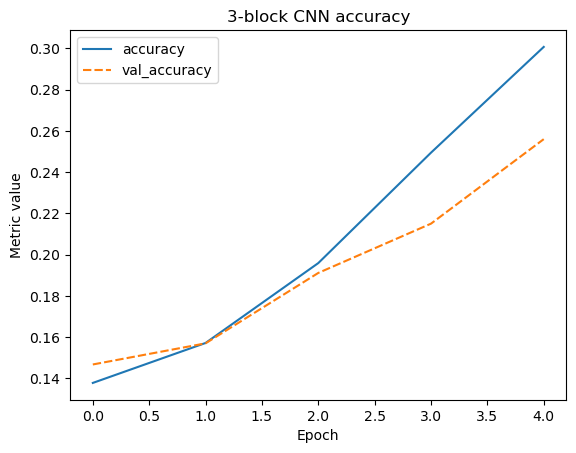

In [24]:
start_time = time.time()
history_3block = model_3block.fit(
    train_images, train_labels,
    epochs=5,
    validation_data=(val_images, val_labels)
)
elapsed = time.time() - start_time
print(f"\nTraining completed in {elapsed:.1f}s")

plot_history(history_3block, ['accuracy', 'val_accuracy'])
plt.title("3-block CNN accuracy")
plt.show()

## 11. Dropout Regularisation

Dropout randomly zeroes a fraction of activations during each training step. This prevents co-adaptation of neurons and acts as a strong regulariser. Here we sweep over several dropout rates to find the best value.

In [25]:
def create_nn_with_dropout(dropout_rate, input_shape):
    """3-block CNN with a configurable dropout rate after each MaxPool layer."""    
    inputs  = keras.Input(shape=input_shape)
    x       = keras.layers.Conv2D(filters=50, kernel_size=(3, 3), activation='relu')(inputs)
    x       = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x       = keras.layers.Dropout(dropout_rate)(x)
    x       = keras.layers.Conv2D(filters=50, kernel_size=(3, 3), activation='relu')(x)
    x       = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x       = keras.layers.Dropout(dropout_rate)(x)
    x       = keras.layers.Conv2D(filters=50, kernel_size=(3, 3), activation='relu')(x)
    x       = keras.layers.Dropout(dropout_rate)(x)
    x       = keras.layers.Flatten()(x)
    x       = keras.layers.Dense(units=50, activation='relu')(x)
    outputs = keras.layers.Dense(units=10)(x)
    return keras.Model(inputs=inputs, outputs=outputs, name="dropout_model")

early_stopper = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

  dropout=0.20  val_loss=2.4455
  dropout=0.40  val_loss=2.2470
  dropout=0.60  val_loss=2.2835
  dropout=0.80  val_loss=2.3008
  dropout=0.90  val_loss=2.3010
  dropout=0.95  val_loss=2.3005

Sweep completed in 124.3s


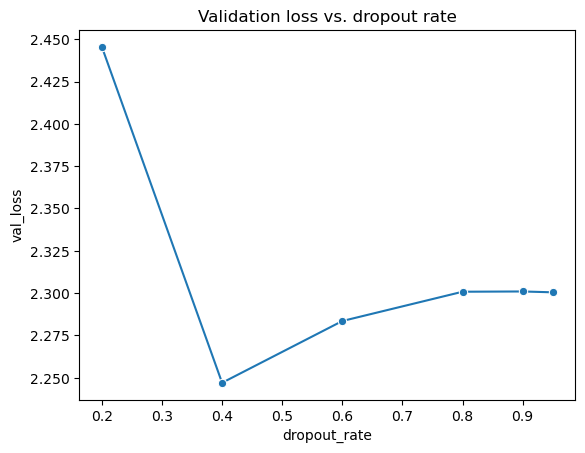

In [26]:
dropout_rates = [0.2, 0.4, 0.6, 0.8, 0.9, 0.95]
val_losses    = []

start_time = time.time()
for rate in dropout_rates:
    m = create_nn_with_dropout(rate, train_images.shape[1:])
    compile_model(m)
    m.fit(train_images, train_labels,
          epochs=30,
          validation_data=(val_images, val_labels),
          callbacks=[early_stopper],
          verbose=0)
    val_loss, _ = m.evaluate(val_images, val_labels, verbose=0)
    val_losses.append(val_loss)
    print(f"  dropout={rate:.2f}  val_loss={val_loss:.4f}")

elapsed = time.time() - start_time
print(f"\nSweep completed in {elapsed:.1f}s")

loss_df = pd.DataFrame({'dropout_rate': dropout_rates, 'val_loss': val_losses})
sns.lineplot(data=loss_df, x='dropout_rate', y='val_loss', marker='o')
plt.title("Validation loss vs. dropout rate")
plt.show()

## 12. Automated Hyperparameter Search with Keras Tuner

Instead of manual sweeps, Keras Tuner systematically explores a search space and records results. Here we run two separate grid searches:
1. Number of Conv blocks (`n_layers`) and dropout rate.
2. Kernel size and activation function.

### 12a. Search: n_layers × dropout_rate

In [34]:
def create_nn_with_hp(dropout_rate, n_layers):
    inputs = keras.Input(shape=train_images.shape[1:])
    x = inputs
    for _ in range(n_layers):
        x = keras.layers.Conv2D(filters=50, kernel_size=(3, 3), activation='relu')(x)
        x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = keras.layers.Dropout(dropout_rate)(x)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(units=50, activation='relu')(x)
    outputs = keras.layers.Dense(units=10)(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name="cifar_model")
    return model

In [35]:
# Start the timer
start_time = time.time()

import keras_tuner

hp = keras_tuner.HyperParameters()

def build_model(hp):
    # Define values for hyperparameters to try out:
    n_layers = hp.Int("n_layers", min_value=1, max_value=2, step=1)
    dropout_rate = hp.Float("dropout_rate", min_value=0.2, max_value=0.8, step=0.3)

    model = create_nn_with_hp(dropout_rate, n_layers)
    compile_model(model)
    return model

tuner = keras_tuner.GridSearch(
    build_model,
    objective='val_loss',
    overwrite=True #Forces a fresh run
)

tuner.search(train_images, 
             train_labels, 
             epochs=20,
             validation_data=(val_images, val_labels))


# Calculate and display the elapsed time
end_time = time.time()
elapsed_time = end_time - start_time

print(f"\nTraining completed in {elapsed_time:.2f} seconds or {elapsed_time/60:.2f} minutes")

Trial 6 Complete [00h 00m 59s]
val_loss: 2.124485969543457

Best val_loss So Far: 2.070046901702881
Total elapsed time: 00h 06m 35s

Training completed in 395.26 seconds or 6.59 minutes


In [36]:
tuner.results_summary()

Results summary
Results in ./untitled_project
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 0002 summary
Hyperparameters:
n_layers: 1
dropout_rate: 0.8
Score: 2.070046901702881

Trial 0000 summary
Hyperparameters:
n_layers: 1
dropout_rate: 0.2
Score: 2.0867486000061035

Trial 0004 summary
Hyperparameters:
n_layers: 2
dropout_rate: 0.5
Score: 2.097299814224243

Trial 0001 summary
Hyperparameters:
n_layers: 1
dropout_rate: 0.5
Score: 2.109302043914795

Trial 0003 summary
Hyperparameters:
n_layers: 2
dropout_rate: 0.2
Score: 2.1197242736816406

Trial 0005 summary
Hyperparameters:
n_layers: 2
dropout_rate: 0.8
Score: 2.124485969543457


### 12b. Search: kernel_size × activation

In [48]:
def create_nn_with_hp(activation_function, kernel_size):
    inputs = keras.Input(shape=train_images.shape[1:])
    x = inputs
    for layer in range(3):
        x = keras.layers.Conv2D(filters=50, kernel_size=(kernel_size, kernel_size), activation=activation_function)(x)
        x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = keras.layers.Dropout(rate=0.2)(x)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(units=50, activation=activation_function)(x)
    outputs = keras.layers.Dense(units=10)(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name="cifar_model")
    return model

hp = keras_tuner.HyperParameters()

def build_model(hp):
    kernel_size = hp.Int("kernel_size", min_value=3, max_value=4, step=1)
    activation = hp.Choice("activation", ["relu", "tanh"])
    model = create_nn_with_hp(activation, kernel_size)
    compile_model(model)
    return model

tuner_v2 = keras_tuner.GridSearch(build_model, 
                               objective='val_loss', 
                               project_name='new_project')


Reloading Tuner from ./new_project/tuner0.json


In [49]:
start_time = time.time()


tuner_v2.search(train_images, 
             train_labels, 
             epochs=20,
             validation_data=(val_images, val_labels)
            )


elapsed = time.time() - start_time
print(f"\nSearch completed in {elapsed:.1f}s")



Search completed in 0.0s


In [50]:
tuner_v2.results_summary()

Results summary
Results in ./new_project
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 0001 summary
Hyperparameters:
kernel_size: 3
activation: tanh
Score: 1.9949814081192017

Trial 0003 summary
Hyperparameters:
kernel_size: 4
activation: tanh
Score: 2.053041458129883

Trial 0000 summary
Hyperparameters:
kernel_size: 3
activation: relu
Score: 2.137178897857666

Trial 0002 summary
Hyperparameters:
kernel_size: 4
activation: relu
Score: 2.1669247150421143


## 13. Save Best Model (Optional)

In [ ]:
# best_model = tuner_v1.get_best_models(num_models=1)[0]
# best_model.save('cnn_model.keras')

## References

- Course: [Introduction to Deep Learning (Carpentries)](https://carpentries-lab.github.io/deep-learning-intro/)
- [Dollar Street dataset on Zenodo](https://zenodo.org/records/10970014)
- [Keras Conv2D docs](https://keras.io/api/layers/convolution_layers/convolution2d/)
- [Keras Tuner docs](https://keras.io/keras_tuner/)
- [Dropout: Srivastava et al. 2014](https://jmlr.org/papers/v15/srivastava14a.html)